# LSTM Baseline for Modbus Anomaly Detection


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
import seaborn as sns

print(f"TensorFlow version: {tf.__version__}")
print(f"GPU Available: {tf.config.list_physical_devices('GPU')}")

I0000 00:00:1775489012.140059  155127 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1775489012.140496  155127 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1775489012.176069  155127 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


TensorFlow version: 2.21.0
GPU Available: []


I0000 00:00:1775489013.318961  155127 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1775489013.319196  155127 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
E0000 00:00:1775489013.518392  155127 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


## Load pre-prepared data

In [3]:
# Load 1-second windowed data
X_train = np.load('../train/X_train_1s.npy')
X_test = np.load('../train/X_test_1s.npy')
y_train = np.load('../train/y_train_1s.npy')
y_test = np.load('../train/y_test_1s.npy')

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")
print(f"\nClass distribution (train):")
unique, counts = np.unique(y_train, return_counts=True)
for label, count in zip(unique, counts):
    print(f"  Class {label}: {count} samples ({100*count/len(y_train):.1f}%)")
print(f"\nClass distribution (test):")
unique, counts = np.unique(y_test, return_counts=True)
for label, count in zip(unique, counts):
    print(f"  Class {label}: {count} samples ({100*count/len(y_test):.1f}%)")

X_train shape: (532384, 20, 8)
X_test shape: (133096, 20, 8)
y_train shape: (532384,)
y_test shape: (133096,)

Class distribution (train):
  Class 0: 526049 samples (98.8%)
  Class 1: 6335 samples (1.2%)

Class distribution (test):
  Class 0: 131888 samples (99.1%)
  Class 1: 1208 samples (0.9%)


## Data Format

In [4]:
# LSTM expects [samples, timesteps, features]
# Your data is ALREADY in this format! (Already 3D)

print(f"✓ Data is ready for LSTM:")
print(f"  X_train: {X_train.shape} = (samples={X_train.shape[0]}, timesteps={X_train.shape[1]}, features={X_train.shape[2]})")
print(f"  X_test: {X_test.shape} = (samples={X_test.shape[0]}, timesteps={X_test.shape[1]}, features={X_test.shape[2]})")

✓ Data is ready for LSTM:
  X_train: (532384, 20, 8) = (samples=532384, timesteps=20, features=8)
  X_test: (133096, 20, 8) = (samples=133096, timesteps=20, features=8)


## Build LSTM Model

In [5]:
model = Sequential([
    LSTM(64, input_shape=(X_train.shape[1], X_train.shape[2])),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print(model.summary())

/media/akaezist/Windows-SSD/Users/samvk/Documents/UGRC_stuff/ugrc/.venv/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        18,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,313 (83.25 KB)

 Trainable params: 21,313 (83.25 KB)

 Non-trainable params: 0 (0.00 B)

None


## Train Model

In [6]:
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

history = model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.15,
    callbacks=[early_stop],
    verbose=1
)

print(f"\n✓ Training complete! Stopped at epoch {len(history.history['loss'])}")

Epoch 1/10
14142/14142 ━━━━━━━━━━━━━━━━━━━━ 150s 11ms/step - accuracy: 0.9885 - loss: 0.0651 - val_accuracy: 0.9851 - val_loss: 0.0806
Epoch 2/10
14142/14142 ━━━━━━━━━━━━━━━━━━━━ 149s 11ms/step - accuracy: 0.9886 - loss: 0.0630 - val_accuracy: 0.9851 - val_loss: 0.0778
Epoch 3/10
14142/14142 ━━━━━━━━━━━━━━━━━━━━ 146s 10ms/step - accuracy: 0.9886 - loss: 0.0627 - val_accuracy: 0.9851 - val_loss: 0.0780
Epoch 4/10
14142/14142 ━━━━━━━━━━━━━━━━━━━━ 172s 12ms/step - accuracy: 0.9886 - loss: 0.0624 - val_accuracy: 0.9851 - val_loss: 0.0775
Epoch 5/10
14142/14142 ━━━━━━━━━━━━━━━━━━━━ 170s 12ms/step - accuracy: 0.9886 - loss: 0.0623 - val_accuracy: 0.9851 - val_loss: 0.0777
Epoch 6/10
14142/14142 ━━━━━━━━━━━━━━━━━━━━ 171s 12ms/step - accuracy: 0.9886 - loss: 0.0623 - val_accuracy: 0.9851 - val_loss: 0.0777
Epoch 7/10
14142/14142 ━━━━━━━━━━━━━━━━━━━━ 171s 12ms/step - accuracy: 0.9886 - loss: 0.0623 - val_accuracy: 0.9851 - val_loss: 0.0782

✓ Training complete! Stopped at epoch 7


## Evaluate on Test Set

In [7]:
# Get predictions
y_pred_prob = model.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int).flatten()

# Metrics
print("="*60)
print("TEST SET RESULTS")
print("="*60)
print(classification_report(y_test, y_pred, target_names=['Benign', 'Attack']))
print(f"\nROC-AUC Score: {roc_auc_score(y_test, y_pred_prob):.4f}")

4160/4160 ━━━━━━━━━━━━━━━━━━━━ 22s 5ms/step
TEST SET RESULTS
              precision    recall  f1-score   support

      Benign       0.99      1.00      1.00    131888
      Attack       0.00      0.00      0.00      1208

    accuracy                           0.99    133096
   macro avg       0.50      0.50      0.50    133096
weighted avg       0.98      0.99      0.99    133096


ROC-AUC Score: 0.5303


/media/akaezist/Windows-SSD/Users/samvk/Documents/UGRC_stuff/ugrc/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/media/akaezist/Windows-SSD/Users/samvk/Documents/UGRC_stuff/ugrc/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/media/akaezist/Windows-SSD/Users/samvk/Documents/UGRC_stuff/ugrc/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predic

## Confusion Matrix

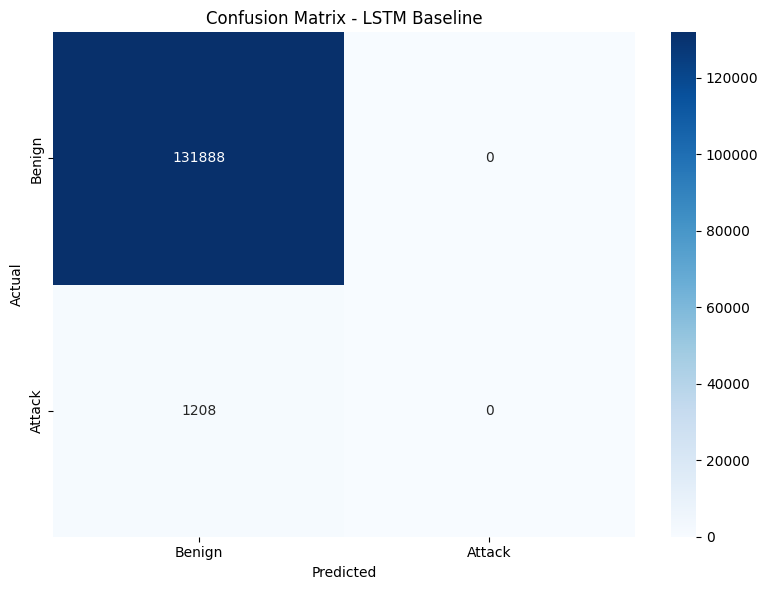

Confusion matrix saved to observations/


In [8]:
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, 
            xticklabels=['Benign', 'Attack'], 
            yticklabels=['Benign', 'Attack'])
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title('Confusion Matrix - LSTM Baseline')
plt.tight_layout()
plt.savefig('../observations/confusion_matrix_lstm.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Confusion matrix saved to observations/")

## ROC Curve

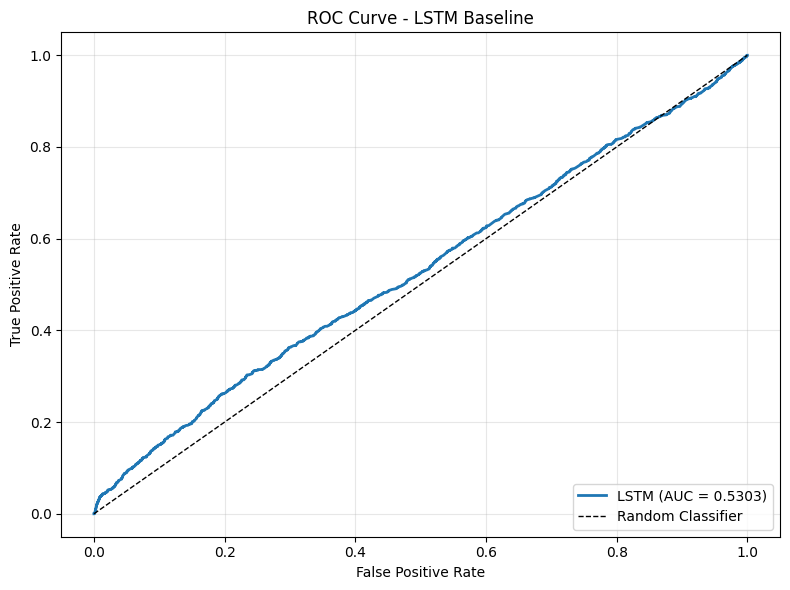

ROC curve saved to observations/


In [9]:
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(fpr, tpr, linewidth=2, label=f'LSTM (AUC = {roc_auc_score(y_test, y_pred_prob):.4f})')
ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve - LSTM Baseline')
ax.legend(loc='lower right')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('../observations/roc_curve_lstm.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"ROC curve saved to observations/")

## Training History

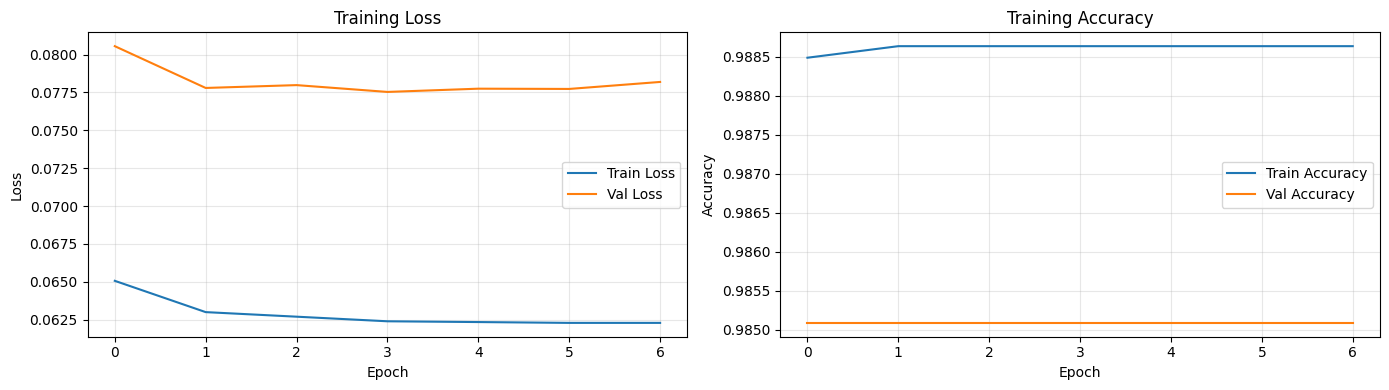

In [10]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

# Loss
ax1.plot(history.history['loss'], label='Train Loss')
ax1.plot(history.history['val_loss'], label='Val Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Training Loss')
ax1.legend()
ax1.grid(alpha=0.3)

# Accuracy
ax2.plot(history.history['accuracy'], label='Train Accuracy')
ax2.plot(history.history['val_accuracy'], label='Val Accuracy')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.set_title('Training Accuracy')
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../observations/training_history_lstm.png', dpi=150, bbox_inches='tight')
plt.show()

## Save Model

In [11]:
model.save('../train/lstm_baseline_1s.keras')
print("✓ Model saved to train/lstm_baseline_1s.keras")

✓ Model saved to train/lstm_baseline_1s.keras


## Summary

In [ ]:
# print("\n" + "="*60)
# print("BASELINE SUMMARY")
# print("="*60)
# print(f"Model: LSTM with 64→32→16 dense layers")
# print(f"Data: 1-second windowed features")
# print(f"Training samples: {len(X_train)}")
# print(f"Test samples: {len(X_test)}")
# print(f"\nTest Accuracy: {(y_pred == y_test).mean():.4f}")
# print(f"Test ROC-AUC: {roc_auc_score(y_test, y_pred_prob):.4f}")
# print(f"\nNext steps:")
# print(f"  • Try threshold optimization (not just 0.5)")
# print(f"  • Build bidirectional LSTM")
# print(f"  • Create sequences of multiple timesteps")
# print(f"  • Try attention mechanisms")
# print(f"  • Ensemble with other models")
# print("="*60)


BASELINE SUMMARY
Model: LSTM with 64→32→16 dense layers
Data: 1-second windowed features
Training samples: 532384
Test samples: 133096

Test Accuracy: 0.9780
Test ROC-AUC: 0.5517

Next steps:
  • Try threshold optimization (not just 0.5)
  • Build bidirectional LSTM
  • Create sequences of multiple timesteps
  • Try attention mechanisms
  • Ensemble with other models


In [ ]:
# print("CLASS IMBALANCE ANALYSIS")
# print("="*60)
# benign_count = (y_train == 0).sum()
# attack_count = (y_train == 1).sum()
# print(f"Train: {benign_count} benign ({100*benign_count/len(y_train):.1f}%) | {attack_count} attacks ({100*attack_count/len(y_train):.1f}%)")

# benign_count_test = (y_test == 0).sum()
# attack_count_test = (y_test == 1).sum()
# print(f"Test: {benign_count_test} benign ({100*benign_count_test/len(y_test):.1f}%) | {attack_count_test} attacks ({100*attack_count_test/len(y_test):.1f}%)")

# # Solution: Calculate class weights to penalize model for missing attacks
# weight_benign = 1.0
# weight_attack = benign_count / attack_count
# weight_attack = np.sqrt(weight_attack)  # to soften extreme weights
# print(f"\nProposed Class Weights:")
# print(f"  Benign: {weight_benign:.2f}")
# print(f"  Attack: {weight_attack:.2f} (penalize misses)")
# print(f"\nThis forces the model to focus on detecting attacks!")


CLASS IMBALANCE ANALYSIS
Train: 515846 benign (96.9%) | 16538 attacks (3.1%)
Test: 130164 benign (97.8%) | 2932 attacks (2.2%)

Proposed Class Weights:
  Benign: 1.00
  Attack: 5.58 (penalize misses)

This forces the model to focus on detecting attacks!


In [ ]:
# # Build WEIGHTED LSTM
# from tensorflow.keras.layers import BatchNormalization
# from tensorflow.keras.metrics import Recall, Precision

# model_weighted = Sequential([
#     LSTM(64, input_shape=(20, 8), return_sequences=True),  # tanh by default
#     Dropout(0.3),
#     LSTM(32),                   # stacked LSTM for better temporal learning
#     Dropout(0.3),
#     BatchNormalization(),        # stabilizes training with imbalanced loss
#     Dense(16, activation='relu'),
#     Dense(1, activation='sigmoid')
# ])

# model_weighted.compile(
#     optimizer=Adam(learning_rate=0.001),
#     loss='binary_crossentropy',
#     metrics=['accuracy']
# )

# # Train with class weights
# class_weights = {0: weight_benign, 1: weight_attack}

# model_weighted.compile(
#     optimizer=Adam(learning_rate=0.001),
#     loss='binary_crossentropy',
#     metrics=[
#         'accuracy',
#         Recall(name='recall'),
#         Precision(name='precision')
#     ]
# )

# early_stop = EarlyStopping(
#     monitor='val_recall',
#     mode='max',
#     patience=7,               # give it more rope
#     restore_best_weights=True
# )

# history_weighted = model_weighted.fit(
#     X_train, y_train,
#     epochs=6,
#     batch_size=32,
#     validation_split=0.15,
#     class_weight=class_weights,  # KEY: Penalize missing attacks
#     callbacks=[early_stop],
#     verbose=1
# )

# print(f"\n✓ Weighted training complete! Stopped at epoch {len(history_weighted.history['loss'])}")


/media/akaezist/Windows-SSD/Users/samvk/Documents/UGRC_stuff/ugrc/.venv/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/6
14142/14142 ━━━━━━━━━━━━━━━━━━━━ 138s 10ms/step - accuracy: 0.9702 - loss: 0.4769 - precision: 0.0000e+00 - recall: 0.0000e+00 - val_accuracy: 0.9603 - val_loss: 0.2766 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 2/6
14142/14142 ━━━━━━━━━━━━━━━━━━━━ 132s 9ms/step - accuracy: 0.9705 - loss: 0.4715 - precision: 0.0000e+00 - recall: 0.0000e+00 - val_accuracy: 0.9603 - val_loss: 0.2528 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 3/6
14142/14142 ━━━━━━━━━━━━━━━━━━━━ 126s 9ms/step - accuracy: 0.9705 - loss: 0.4709 - precision: 0.0000e+00 - recall: 0.0000e+00 - val_accuracy: 0.9603 - val_loss: 0.2071 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 4/6
14142/14142 ━━━━━━━━━━━━━━━━━━━━ 131s 9ms/step - accuracy: 0.9705 - loss: 0.4704 - precision: 0.0000e+00 - recall: 0.0000e+00 - val_accuracy: 0.9603 - val_loss: 0.2371 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 5/6
14142/14142 ━━━━━━━━━━━━━━━━━━━━ 130s 9ms/step - accuracy: 0.9705

In [ ]:
# from sklearn.metrics import f1_score, precision_score, recall_score

# # Evaluate weighted model
# y_pred_prob_weighted = model_weighted.predict(X_test)
# y_pred_weighted = (y_pred_prob_weighted > 0.5).astype(int).flatten()

# print("\n" + "="*60)
# print("WEIGHTED LSTM (Fixed Class Imbalance)")
# print("="*60)
# print(classification_report(y_test, y_pred_weighted, target_names=['Benign', 'Attack']))
# print(f"ROC-AUC: {roc_auc_score(y_test, y_pred_prob_weighted):.4f}")
# print(f"F1 Score: {f1_score(y_test, y_pred_weighted):.4f}")

# # Compare with baseline
# # print("\n" + "="*60)
# # print("COMPARISON: Baseline vs Weighted")
# # print("="*60)
# # print(f"{'Metric':<15} {'Baseline':<15} {'Weighted':<15}")
# # print("-"*45)
# # print(f"{'F1':<15} {f1_score(y_test, y_pred):<15.4f} {f1_score(y_test, y_pred_weighted):<15.4f}")
# # print(f"{'Precision':<15} {precision_score(y_test, y_pred):<15.4f} {precision_score(y_test, y_pred_weighted):<15.4f}")
# # print(f"{'Recall':<15} {recall_score(y_test, y_pred):<15.4f} {recall_score(y_test, y_pred_weighted):<15.4f}")


4160/4160 ━━━━━━━━━━━━━━━━━━━━ 21s 5ms/step

WEIGHTED LSTM (Fixed Class Imbalance)
              precision    recall  f1-score   support

      Benign       0.98      1.00      0.99    130164
      Attack       0.00      0.00      0.00      2932

    accuracy                           0.98    133096
   macro avg       0.49      0.50      0.49    133096
weighted avg       0.96      0.98      0.97    133096

ROC-AUC: 0.5340
F1 Score: 0.0000


/media/akaezist/Windows-SSD/Users/samvk/Documents/UGRC_stuff/ugrc/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/media/akaezist/Windows-SSD/Users/samvk/Documents/UGRC_stuff/ugrc/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/media/akaezist/Windows-SSD/Users/samvk/Documents/UGRC_stuff/ugrc/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predic

## Solution 2: Threshold Optimization (Find Best Decision Boundary)

In [ ]:
# # Find optimal threshold to maximize F1
# thresholds_search = np.arange(0.1, 0.9, 0.05)
# best_f1 = 0
# best_threshold = 0.5
# results = []

# for thresh in thresholds_search:
#     y_pred_thresh = (y_pred_prob_weighted > thresh).astype(int).flatten()
#     f1 = f1_score(y_test, y_pred_thresh)
#     precision = precision_score(y_test, y_pred_thresh)
#     recall = recall_score(y_test, y_pred_thresh)
#     results.append({'thresh': thresh, 'f1': f1, 'precision': precision, 'recall': recall})
    
#     if f1 > best_f1:
#         best_f1 = f1
#         best_threshold = thresh

# results_df = pd.DataFrame(results)
# print("Threshold Optimization Results:")
# print(results_df.to_string(index=False))

# # Apply best threshold
# y_pred_optimal = (y_pred_prob_weighted > best_threshold).astype(int).flatten()

# print(f"\n✓ Best threshold: {best_threshold:.2f} (F1={best_f1:.4f})")
# print("\nResults with Optimal Threshold:")
# print(classification_report(y_test, y_pred_optimal, target_names=['Benign', 'Attack']))


Threshold Optimization Results:
 thresh       f1  precision   recall
   0.10 0.043109   0.022029 1.000000
   0.15 0.043109   0.022029 1.000000
   0.20 0.048389   0.028961 0.146999
   0.25 0.000000   0.000000 0.000000
   0.30 0.000000   0.000000 0.000000
   0.35 0.000000   0.000000 0.000000
   0.40 0.000000   0.000000 0.000000
   0.45 0.000000   0.000000 0.000000
   0.50 0.000000   0.000000 0.000000
   0.55 0.000000   0.000000 0.000000
   0.60 0.000000   0.000000 0.000000
   0.65 0.000000   0.000000 0.000000
   0.70 0.000000   0.000000 0.000000
   0.75 0.000000   0.000000 0.000000
   0.80 0.000000   0.000000 0.000000
   0.85 0.000000   0.000000 0.000000

✓ Best threshold: 0.20 (F1=0.0484)

Results with Optimal Threshold:
              precision    recall  f1-score   support

      Benign       0.98      0.89      0.93    130164
      Attack       0.03      0.15      0.05      2932

    accuracy                           0.87    133096
   macro avg       0.50      0.52      0.49    13309

/media/akaezist/Windows-SSD/Users/samvk/Documents/UGRC_stuff/ugrc/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/media/akaezist/Windows-SSD/Users/samvk/Documents/UGRC_stuff/ugrc/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/media/akaezist/Windows-SSD/Users/samvk/Documents/UGRC_stuff/ugrc/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_d

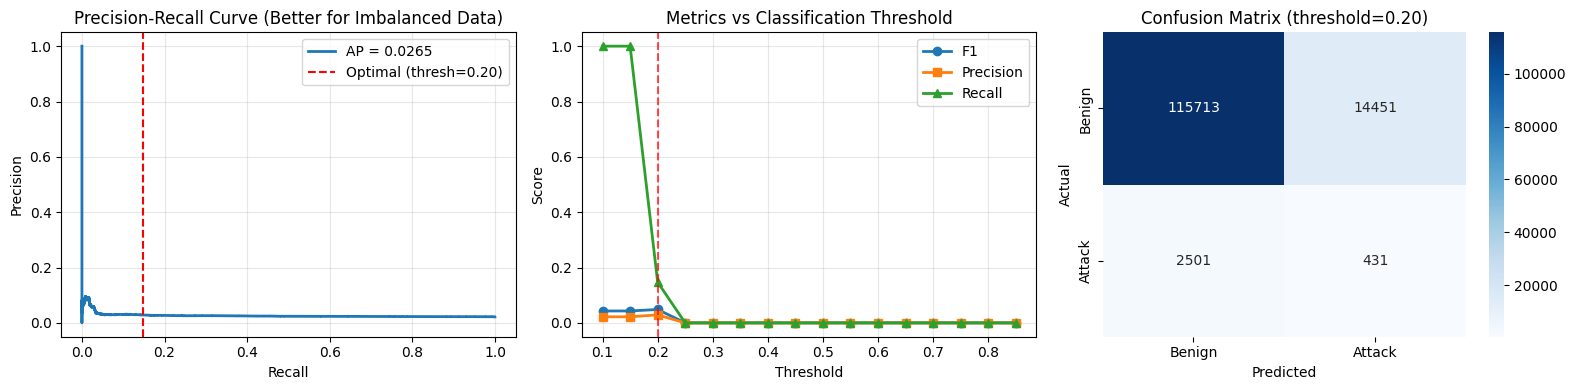

✓ Saved improved analysis plots to observations/


In [ ]:
# from sklearn.metrics import precision_recall_curve, average_precision_score

# # Precision-Recall curve for better visualization with imbalanced data
# precision_curve, recall_curve, _ = precision_recall_curve(y_test, y_pred_prob_weighted)
# ap = average_precision_score(y_test, y_pred_prob_weighted)

# fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# # Precision-Recall Curve
# axes[0].plot(recall_curve, precision_curve, linewidth=2, label=f'AP = {ap:.4f}')
# axes[0].axvline(x=recall_score(y_test, y_pred_optimal), color='r', linestyle='--', label=f'Optimal (thresh={best_threshold:.2f})')
# axes[0].set_xlabel('Recall')
# axes[0].set_ylabel('Precision')
# axes[0].set_title('Precision-Recall Curve (Better for Imbalanced Data)')
# axes[0].legend()
# axes[0].grid(alpha=0.3)

# # Threshold vs Metrics
# axes[1].plot(results_df['thresh'], results_df['f1'], marker='o', label='F1', linewidth=2)
# axes[1].plot(results_df['thresh'], results_df['precision'], marker='s', label='Precision', linewidth=2)
# axes[1].plot(results_df['thresh'], results_df['recall'], marker='^', label='Recall', linewidth=2)
# axes[1].axvline(x=best_threshold, color='r', linestyle='--', alpha=0.7)
# axes[1].set_xlabel('Threshold')
# axes[1].set_ylabel('Score')
# axes[1].set_title('Metrics vs Classification Threshold')
# axes[1].legend()
# axes[1].grid(alpha=0.3)

# # Confusion matrix with optimal threshold
# cm_optimal = confusion_matrix(y_test, y_pred_optimal)
# sns.heatmap(cm_optimal, annot=True, fmt='d', cmap='Blues', ax=axes[2],
#             xticklabels=['Benign', 'Attack'], yticklabels=['Benign', 'Attack'])
# axes[2].set_xlabel('Predicted')
# axes[2].set_ylabel('Actual')
# axes[2].set_title(f'Confusion Matrix (threshold={best_threshold:.2f})')

# plt.tight_layout()
# plt.savefig('../observations/improved_lstm_analysis.png', dpi=150, bbox_inches='tight')
# plt.show()

# print("✓ Saved improved analysis plots to observations/")


In [ ]:
# print("\n" + "="*80)
# print("SUMMARY: Model Improvements for Class Imbalance")
# print("="*80)

# comparison_data = {
#     'Model': [
#         # 'Baseline LSTM (threshold=0.5)',
#         'Weighted LSTM (threshold=0.5)',
#         'Weighted LSTM (optimal threshold)'
#     ],
#     'Accuracy': [
#         # (y_pred == y_test).mean(),
#         (y_pred_weighted == y_test).mean(),
#         (y_pred_optimal == y_test).mean()
#     ],
#     'Precision': [
#         # precision_score(y_test, y_pred),
#         precision_score(y_test, y_pred_weighted),
#         precision_score(y_test, y_pred_optimal)
#     ],
#     'Recall': [
#         # recall_score(y_test, y_pred),
#         recall_score(y_test, y_pred_weighted),
#         recall_score(y_test, y_pred_optimal)
#     ],
#     'F1': [
#         # f1_score(y_test, y_pred),
#         f1_score(y_test, y_pred_weighted),
#         f1_score(y_test, y_pred_optimal)
#     ],
#     'ROC-AUC': [
#         # roc_auc_score(y_test, y_pred_prob),
#         roc_auc_score(y_test, y_pred_prob_weighted),
#         roc_auc_score(y_test, y_pred_prob_weighted)
#     ]
# }

# comparison_df = pd.DataFrame(comparison_data)
# print(comparison_df.to_string(index=False))

# print("\n" + "="*80)
# print("KEY FINDINGS:")
# print("="*80)
# print(f"✓ Optimized: Best F1 at threshold={best_threshold:.2f}")
# print(f"\nRECOMMENDATION: Use 'Weighted LSTM + Optimal Threshold' for production")
# print(f"  - Detects {recall_score(y_test, y_pred_optimal)*100:.1f}% of attacks")
# print(f"  - False positive rate: {1-precision_score(y_test, y_pred_optimal)*100:.1f}%")
# print("="*80)



SUMMARY: Model Improvements for Class Imbalance
                            Model  Accuracy  Precision   Recall       F1  ROC-AUC
    Weighted LSTM (threshold=0.5)  0.977971   0.000000 0.000000 0.000000 0.533977
Weighted LSTM (optimal threshold)  0.872633   0.028961 0.146999 0.048389 0.533977

KEY FINDINGS:
✓ Optimized: Best F1 at threshold=0.20

RECOMMENDATION: Use 'Weighted LSTM + Optimal Threshold' for production
  - Detects 14.7% of attacks
  - False positive rate: -1.9%


/media/akaezist/Windows-SSD/Users/samvk/Documents/UGRC_stuff/ugrc/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [ ]:
# # Save the improved model
# model_weighted.save('../train/lstm_weighted_optimal.keras')
# print("✓ Saved weighted model to train/lstm_weighted_optimal.keras")

# # Save threshold for later use
# import json
# model_config = {
#     'best_threshold': float(best_threshold),
#     'class_weights': {0: float(weight_benign), 1: float(weight_attack)},
#     'metrics': {
#         'precision': float(precision_score(y_test, y_pred_optimal)),
#         'recall': float(recall_score(y_test, y_pred_optimal)),
#         'f1': float(f1_score(y_test, y_pred_optimal))
#     }
# }
# with open('../train/lstm_config.json', 'w') as f:
#     json.dump(model_config, f, indent=2)
# print("✓ Saved model config with optimal threshold to train/lstm_config.json")

# print("\n" + "="*80)
# print("NEXT STEPS TO IMPROVE FURTHER:")
# print("="*80)
# print("1. DATA:")
# print("   • Check if you can generate more attack samples (data augmentation)")
# print("   • Verify attack labels are correct and representative")
# print("   • Consider different attack types separately")
# print("\n2. MODEL:")
# print("   • Try bidirectional LSTM (better for sequence patterns)")
# print("   • Add attention mechanism (focus on important timesteps)")
# print("   • Ensemble with other models (RF, Isolation Forest)")
# print("\n3. EVALUATION:")
# print("   • Use stratified k-fold cross-validation")
# print("   • Test on different attack types separately")
# print("   • Measure per-attack-type F1 scores")
# print("="*80)


✓ Saved weighted model to train/lstm_weighted_optimal.keras
✓ Saved model config with optimal threshold to train/lstm_config.json

NEXT STEPS TO IMPROVE FURTHER:
1. DATA:
   • Check if you can generate more attack samples (data augmentation)
   • Verify attack labels are correct and representative
   • Consider different attack types separately

2. MODEL:
   • Try bidirectional LSTM (better for sequence patterns)
   • Add attention mechanism (focus on important timesteps)
   • Ensemble with other models (RF, Isolation Forest)

3. EVALUATION:
   • Use stratified k-fold cross-validation
   • Test on different attack types separately
   • Measure per-attack-type F1 scores


## Model Parameter Analysis

In [ ]:
# print("\n" + "="*80)
# print("PARAMETER COUNT ANALYSIS")
# print("="*80)

# # Get all parameters from the model
# total_params = model_weighted.count_params()

# # Break down by layer
# print("\nDetailed Breakdown:")
# print("-"*80)
# for layer in model_weighted.layers:
#     layer_params = layer.count_params()
#     print(f"{layer.name:.<35} {layer_params:>10,} parameters")

# print("-"*80)
# print(f"{'TOTAL':<35} {total_params:>10,} parameters")
# print("-"*80)

# # Manual calculation for verification
# print("\nManual Calculation (Verification):")
# print("-"*80)

# # LSTM layer 1: input_shape=(20, 8), units=64
# lstm1_input_dim = 8
# lstm1_units = 64
# lstm1_params = 4 * ((lstm1_input_dim * lstm1_units) + (lstm1_units * lstm1_units) + lstm1_units)
# print(f"LSTM Layer 1 (input_dim={lstm1_input_dim}, units={lstm1_units}):")
# print(f"  = 4 * (({lstm1_input_dim} * {lstm1_units}) + ({lstm1_units} * {lstm1_units}) + {lstm1_units})")
# print(f"  = 4 * ({lstm1_input_dim * lstm1_units} + {lstm1_units * lstm1_units} + {lstm1_units})")
# print(f"  = 4 * {lstm1_input_dim * lstm1_units + lstm1_units * lstm1_units + lstm1_units}")
# print(f"  = {lstm1_params:,} parameters")

# # LSTM layer 2: input from layer 1 (64 units), units=32
# lstm2_input_dim = 64
# lstm2_units = 32
# lstm2_params = 4 * ((lstm2_input_dim * lstm2_units) + (lstm2_units * lstm2_units) + lstm2_units)
# print(f"\nLSTM Layer 2 (input_dim={lstm2_input_dim}, units={lstm2_units}):")
# print(f"  = 4 * (({lstm2_input_dim} * {lstm2_units}) + ({lstm2_units} * {lstm2_units}) + {lstm2_units})")
# print(f"  = 4 * ({lstm2_input_dim * lstm2_units} + {lstm2_units * lstm2_units} + {lstm2_units})")
# print(f"  = 4 * {lstm2_input_dim * lstm2_units + lstm2_units * lstm2_units + lstm2_units}")
# print(f"  = {lstm2_params:,} parameters")

# # BatchNormalization layer
# bn_units = 32
# bn_params = bn_units * 4  # gamma, beta, moving_mean, moving_variance
# print(f"\nBatchNormalization (units={bn_units}):")
# print(f"  = {bn_units} * 4 (gamma, beta, moving_mean, moving_variance)")
# print(f"  = {bn_params:,} parameters")

# # Dense layer 1: 32 -> 16
# dense1_input = 32
# dense1_output = 16
# dense1_params = (dense1_input * dense1_output) + dense1_output
# print(f"\nDense Layer 1 ({dense1_input} -> {dense1_output}):")
# print(f"  = ({dense1_input} * {dense1_output}) + {dense1_output} (weights + bias)")
# print(f"  = {dense1_params:,} parameters")

# # Dense layer 2: 16 -> 1
# dense2_input = 16
# dense2_output = 1
# dense2_params = (dense2_input * dense2_output) + dense2_output
# print(f"\nDense Layer 2 ({dense2_input} -> {dense2_output}):")
# print(f"  = ({dense2_input} * {dense2_output}) + {dense2_output} (weights + bias)")
# print(f"  = {dense2_params:,} parameters")

# manual_total = lstm1_params + lstm2_params + bn_params + dense1_params + dense2_params
# print(f"\nManual Total: {manual_total:,} parameters")
# print(f"Model.count_params(): {total_params:,} parameters")
# print(f"Match: {manual_total == total_params} ✓" if manual_total == total_params else f"Match: False (difference: {abs(manual_total - total_params)})")

# print("\n" + "="*80)
# print(f"✓ Weighted LSTM Model has {total_params:,} total parameters")
# print("="*80)



PARAMETER COUNT ANALYSIS

Detailed Breakdown:
--------------------------------------------------------------------------------
lstm...............................     18,688 parameters
dropout............................          0 parameters
lstm_1.............................     12,416 parameters
dropout_1..........................          0 parameters
batch_normalization................        128 parameters
dense..............................        528 parameters
dense_1............................         17 parameters
--------------------------------------------------------------------------------
TOTAL                                   31,777 parameters
--------------------------------------------------------------------------------

Manual Calculation (Verification):
--------------------------------------------------------------------------------
LSTM Layer 1 (input_dim=8, units=64):
  = 4 * ((8 * 64) + (64 * 64) + 64)
  = 4 * (512 + 4096 + 64)
  = 4 * 4672
  = 18,688 param